# MES Commission Math Analysis

**Phase 1, Task 5** | MES Micro E-mini S&P 500 Futures

This notebook answers: *What is the minimum viable profit target and required win rate for your broker?*

---

**MES Contract Specs:**
- Tick size: 0.25 points
- Tick value: $1.25
- Point value: $5.00

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.commission_model import (
    CostModel, BrokerComparison,
    tradovate_free, tradovate_lifetime, edgeclear_rithmic, ninjatrader_free,
    all_brokers,
)

sns.set_theme(style="whitegrid")

# Your current broker
YOU = tradovate_free()

# All brokers for comparison
brokers = all_brokers()
comp = BrokerComparison(brokers)

print(f"Current broker: {YOU.broker_name}")
print(f"  Per-side commission: ${YOU.commission_per_side:.2f}")
print(f"  Round-trip commission: ${YOU.round_trip_commission():.2f}")
print(f"  Slippage cost (1 tick/side): ${YOU.slippage_cost():.2f}")
print(f"  Total round-trip cost: ${YOU.round_trip_cost():.2f}")

Current broker: Tradovate Free
  Per-side commission: $0.35
  Round-trip commission: $0.70
  Slippage cost (1 tick/side): $2.50
  Total round-trip cost: $3.20


## 1. Breakeven Win Rate Table

For each (target, stop) combo, what win rate do you need just to break even?

In [2]:
targets = [4, 6, 8, 10, 12, 16, 20]
stops = [2, 3, 4, 6, 8, 10]

print(f"\n{'':=<80}")
print(f"BREAKEVEN WIN RATES — {YOU.broker_name}")
print(f"(1-tick slippage per side assumed)")
print(f"{'':=<80}")

# Header
header = f"{'Target':>8} |" + "".join(f" Stop {s:>2} |" for s in stops)
print(header)
print("-" * len(header))

for t in targets:
    row = f"{t:>5} tk |" 
    for s in stops:
        wr = YOU.breakeven_win_rate(t, s)
        marker = " *" if wr >= 1.0 else "  " if wr < 0.50 else ""  
        row += f"  {wr:5.1%}{marker}|"
    print(row)

print(f"\n* = impossible (net win <= 0 at this target)")
print(f"Blank after % = achievable (breakeven WR < 50%)")


BREAKEVEN WIN RATES — Tradovate Free
(1-tick slippage per side assumed)
  Target | Stop  2 | Stop  3 | Stop  4 | Stop  6 | Stop  8 | Stop 10 |
----------------------------------------------------------------------
    4 tk |  76.0%|  79.4%|  82.0%|  85.6%|  88.0%|  89.7%|
    6 tk |  57.0%|  61.8%|  65.6%|  71.3%|  75.4%|  78.5%|
    8 tk |  45.6%  |  50.5%|  54.7%|  61.1%|  66.0%|  69.8%|
   10 tk |  38.0%  |  42.8%  |  46.9%  |  53.5%|  58.7%|  62.8%|
   12 tk |  32.6%  |  37.1%  |  41.0%  |  47.6%  |  52.8%|  57.1%|
   16 tk |  25.3%  |  29.3%  |  32.8%  |  38.9%  |  44.0%  |  48.3%  |
   20 tk |  20.7%  |  24.2%  |  27.3%  |  32.9%  |  37.7%  |  41.9%  |

* = impossible (net win <= 0 at this target)
Blank after % = achievable (breakeven WR < 50%)


## 2. Breakeven Heatmap

Green = achievable (breakeven WR < 55%). Red = dangerous or impossible.

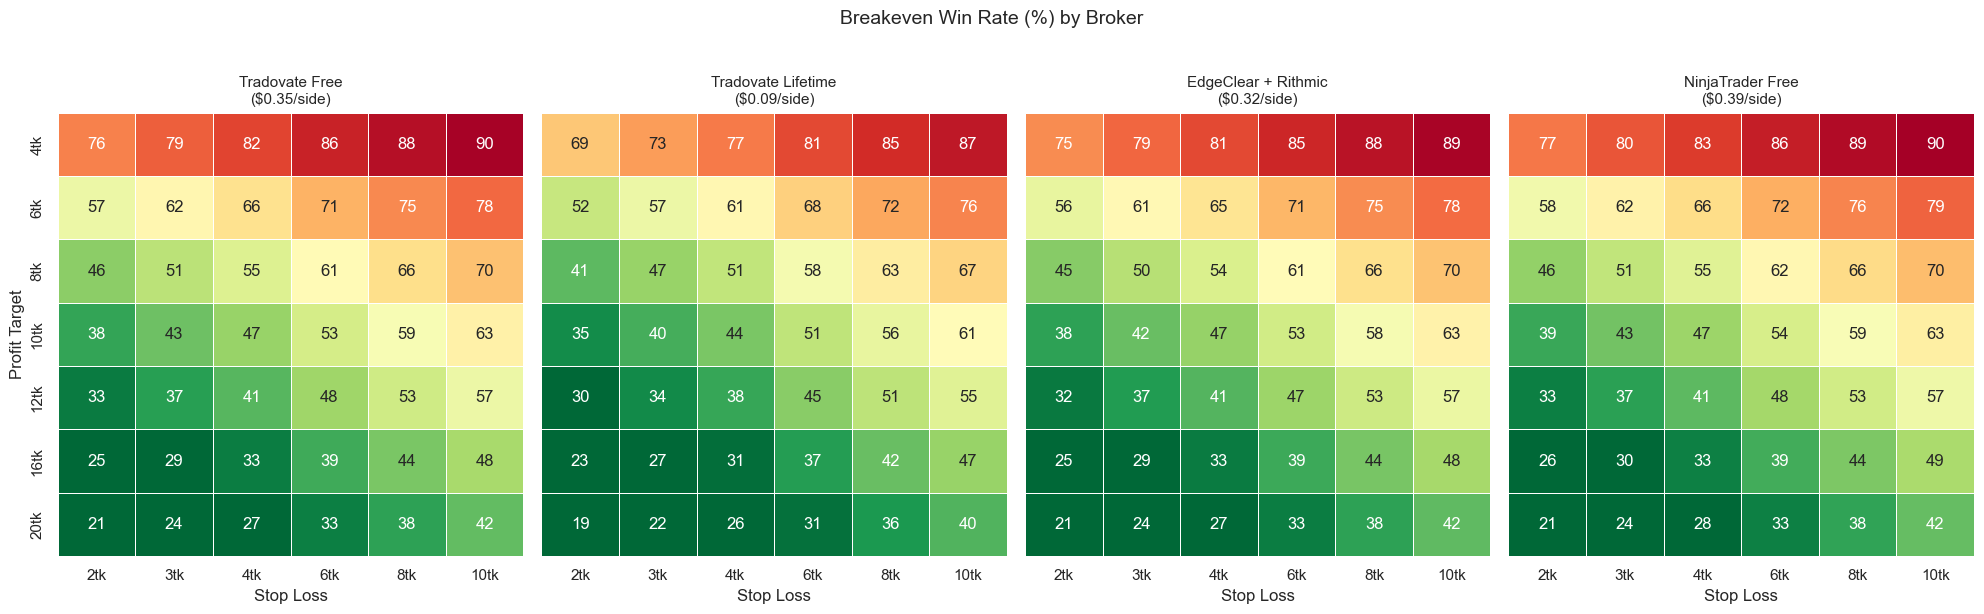

In [3]:
fig, axes = plt.subplots(1, len(brokers), figsize=(5 * len(brokers), 6), sharey=True)

targets = [4, 6, 8, 10, 12, 16, 20]
stops = [2, 3, 4, 6, 8, 10]

for ax, model in zip(axes, brokers):
    matrix = np.array([
        [model.breakeven_win_rate(t, s) * 100 for s in stops]
        for t in targets
    ])
    
    sns.heatmap(
        matrix, ax=ax,
        xticklabels=[f"{s}tk" for s in stops],
        yticklabels=[f"{t}tk" for t in targets],
        annot=True, fmt=".0f", cmap="RdYlGn_r",
        vmin=30, vmax=90, cbar=False,
        linewidths=0.5,
    )
    ax.set_title(f"{model.broker_name}\n(${model.commission_per_side:.2f}/side)", fontsize=11)
    ax.set_xlabel("Stop Loss")
    if ax == axes[0]:
        ax.set_ylabel("Profit Target")

fig.suptitle("Breakeven Win Rate (%) by Broker", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../docs/phase1/breakeven_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Annual Commission Cost

How much do commissions alone cost you per year at different trading frequencies?

In [ ]:
frequencies = [3, 5, 10, 15, 20]

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(frequencies))
width = 0.2

for i, model in enumerate(brokers):
    costs = [model.annual_commission_cost(f) for f in frequencies]
    bars = ax.bar(x + i * width, costs, width, label=model.broker_name)
    for bar, cost in zip(bars, costs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f"${cost:,.0f}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Trades per Day")
ax.set_ylabel("Annual Commission ($)")
ax.set_title("Annual Commission Cost by Broker & Trading Frequency")
ax.set_xticks(x + width * (len(brokers) - 1) / 2)
ax.set_xticklabels([f"{f}/day" for f in frequencies])
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.savefig("../docs/phase1/annual_commission.png", dpi=150, bbox_inches="tight")
plt.show()

# Print table
print(f"\n{'Broker':<25} | " + " | ".join(f"{f}/day" for f in frequencies))
print("-" * 80)
for model in brokers:
    costs = [model.annual_commission_cost(f) for f in frequencies]
    print(f"{model.broker_name:<25} | " + " | ".join(f"${c:>6,.0f}" for c in costs))

## 4. Slippage Sensitivity

How much does slippage shift your breakeven? (8-tick target, 8-tick stop)

In [ ]:
slippage_scenarios = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
target, stop = 8, 8

fig, ax = plt.subplots(figsize=(10, 5))

for model in brokers:
    bwr = []
    for slip in slippage_scenarios:
        m = CostModel(
            broker_name=model.broker_name,
            broker_commission_per_side=model.broker_commission_per_side,
            exchange_fee=model.exchange_fee,
            nfa_fee=model.nfa_fee,
            avg_slippage_ticks=slip,
        )
        bwr.append(m.breakeven_win_rate(target, stop) * 100)
    ax.plot(slippage_scenarios, bwr, marker="o", label=model.broker_name)

ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5, label="50% (coin flip)")
ax.set_xlabel("Avg Slippage (ticks per side)")
ax.set_ylabel("Breakeven Win Rate (%)")
ax.set_title(f"Slippage Impact on Breakeven WR ({target}-tick target, {stop}-tick stop)")
ax.legend()
ax.set_ylim(45, 80)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/phase1/slippage_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

# Print table
print(f"\n{'Slippage':>10} | " + " | ".join(f"{m.broker_name:>20}" for m in brokers))
print("-" * 100)
for slip in slippage_scenarios:
    row = f"{slip:>7.1f} tk |"
    for model in brokers:
        m = CostModel(
            broker_name=model.broker_name,
            broker_commission_per_side=model.broker_commission_per_side,
            exchange_fee=model.exchange_fee,
            nfa_fee=model.nfa_fee,
            avg_slippage_ticks=slip,
        )
        wr = m.breakeven_win_rate(target, stop) * 100
        row += f" {wr:>19.1f}% |"
    print(row)

## 5. Minimum Viable Strategy Parameters

The key table. This determines which strategies are worth building.

In [4]:
print("=" * 80)
print("MINIMUM VIABLE STRATEGY PARAMETERS")
print("=" * 80)

for model in brokers:
    print(f"\n--- {model.broker_name} (${model.commission_per_side:.2f}/side, RT ${model.round_trip_commission():.2f}) ---")
    
    # Min viable target (breakeven WR < 50% at 8-tick stop)
    mvt = model.min_viable_target(stop_ticks=8, max_breakeven_wr=0.50)
    print(f"  Min viable target (vs 8-tick stop): {mvt} ticks (${mvt * model.tick_value:.2f})")
    
    # Required WR at different R:R ratios
    for label, t, s in [("1:1 (8t/8t)", 8, 8), ("1.5:1 (12t/8t)", 12, 8), ("2:1 (16t/8t)", 16, 8)]:
        wr = model.breakeven_win_rate(t, s)
        print(f"  Breakeven WR at {label}: {wr:.1%}")
    
    # Annual cost
    for tpd in [5, 10]:
        cost = model.annual_commission_cost(tpd)
        print(f"  Annual commission at {tpd} trades/day: ${cost:,.0f}")

print(f"\n{'':=<80}")
print("RECOMMENDATION")
print(f"{'':=<80}")
print(f"\nYou are on: {YOU.broker_name}")
mvt = YOU.min_viable_target(stop_ticks=8)
print(f"\nMinimum viable profit target: {mvt} ticks (${mvt * 1.25:.2f})")
print(f"  -> Any strategy targeting < {mvt} ticks is DOA at your commission rate")
print(f"\nAt 8-tick target / 8-tick stop:")
print(f"  Breakeven WR: {YOU.breakeven_win_rate(8, 8):.1%}")
print(f"  Need to sustain > {YOU.breakeven_win_rate(8, 8):.1%} win rate to profit")
print(f"\nUpgrade impact (Tradovate Lifetime):")
lt = tradovate_lifetime()
savings = YOU.annual_commission_cost(5) - lt.annual_commission_cost(5)
print(f"  Commission savings: ${savings:,.0f}/year at 5 trades/day")
print(f"  Breakeven WR drops: {YOU.breakeven_win_rate(8, 8):.1%} -> {lt.breakeven_win_rate(8, 8):.1%}")

MINIMUM VIABLE STRATEGY PARAMETERS

--- Tradovate Free ($0.35/side, RT $0.70) ---
  Min viable target (vs 8-tick stop): 14 ticks ($17.50)
  Breakeven WR at 1:1 (8t/8t): 66.0%
  Breakeven WR at 1.5:1 (12t/8t): 52.8%
  Breakeven WR at 2:1 (16t/8t): 44.0%
  Annual commission at 5 trades/day: $875
  Annual commission at 10 trades/day: $1,750

--- Tradovate Lifetime ($0.09/side, RT $0.18) ---
  Min viable target (vs 8-tick stop): 13 ticks ($16.25)
  Breakeven WR at 1:1 (8t/8t): 63.4%
  Breakeven WR at 1.5:1 (12t/8t): 50.7%
  Breakeven WR at 2:1 (16t/8t): 42.3%
  Annual commission at 5 trades/day: $225
  Annual commission at 10 trades/day: $450

--- EdgeClear + Rithmic ($0.32/side, RT $0.64) ---
  Min viable target (vs 8-tick stop): 14 ticks ($17.50)
  Breakeven WR at 1:1 (8t/8t): 65.7%
  Breakeven WR at 1.5:1 (12t/8t): 52.6%
  Breakeven WR at 2:1 (16t/8t): 43.8%
  Annual commission at 5 trades/day: $800
  Annual commission at 10 trades/day: $1,600

--- NinjaTrader Free ($0.39/side, RT $0.78

## 6. Expected P&L Per Trade

If you achieve a given win rate, what's your expected profit per trade?

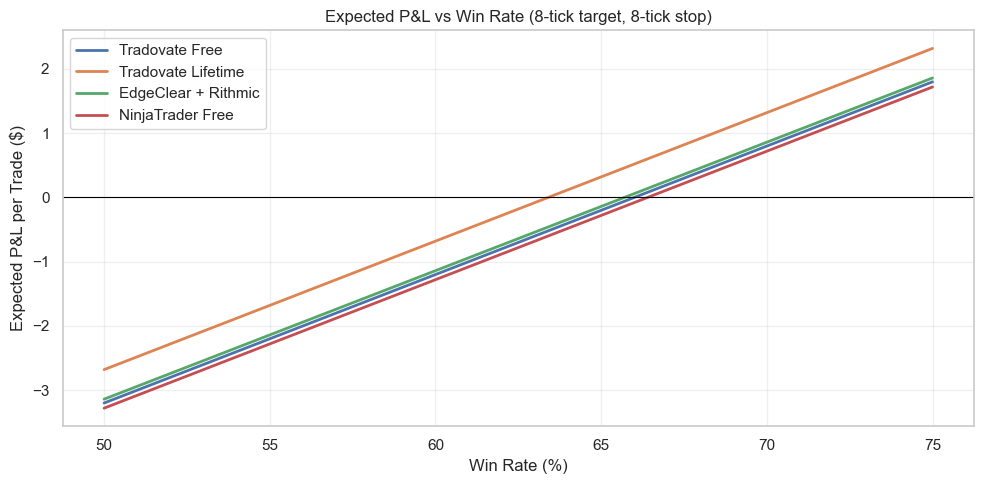


Expected P&L per trade at 8t target / 8t stop:
  Win Rate |       Tradovate Free |   Tradovate Lifetime |  EdgeClear + Rithmic |     NinjaTrader Free
----------------------------------------------------------------------------------------------------
      60% | $              -1.20 | $              -0.68 | $              -1.14 | $              -1.28 |
      65% | $              -0.20 | $               0.32 | $              -0.14 | $              -0.28 |
      68% | $               0.40 | $               0.92 | $               0.46 | $               0.32 |
      70% | $               0.80 | $               1.32 | $               0.86 | $               0.72 |
      75% | $               1.80 | $               2.32 | $               1.86 | $               1.72 |


In [5]:
win_rates = np.arange(0.50, 0.76, 0.01)
target, stop = 8, 8

fig, ax = plt.subplots(figsize=(10, 5))

for model in brokers:
    ev = [model.profit_expectancy(target, stop, wr) for wr in win_rates]
    ax.plot(win_rates * 100, ev, label=model.broker_name, linewidth=2)

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xlabel("Win Rate (%)")
ax.set_ylabel("Expected P&L per Trade ($)")
ax.set_title(f"Expected P&L vs Win Rate ({target}-tick target, {stop}-tick stop)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../docs/phase1/expected_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

# Concrete numbers at key win rates
print(f"\nExpected P&L per trade at 8t target / 8t stop:")
print(f"{'Win Rate':>10} | " + " | ".join(f"{m.broker_name:>20}" for m in brokers))
print("-" * 100)
for wr in [0.60, 0.65, 0.68, 0.70, 0.75]:
    row = f"{wr:>9.0%} |"
    for m in brokers:
        ev = m.profit_expectancy(target, stop, wr)
        row += f" ${ev:>19.2f} |"
    print(row)

## 7. Conclusion

### Key Findings

1. **Minimum viable target is 8 ticks** at Tradovate Free ($0.35/side). Anything below 8 ticks requires an unrealistic win rate.

2. **Breakeven win rate at 1:1 R:R (8t/8t) is ~66%** on the Free plan. This is achievable but demanding. Every strategy must demonstrate > 66% backtested win rate to be worth deploying.

3. **Upgrading to Lifetime saves ~$650/year** and drops the breakeven WR by ~2.5 percentage points. This pays for itself quickly once the bot is trading 5+ times/day.

4. **Slippage is the silent killer.** At 2-tick slippage (volatile markets), breakeven WR jumps to ~72%, making even good strategies unprofitable. Always assume 1-tick slippage in backtests; avoid trading during high-slippage events.

5. **The 5 roadmap strategies all target 8+ ticks**, so they're all viable at Tradovate Free commission rates. No strategy changes needed.

### Action Items

- Use **8-tick minimum target** as the filter for all strategy research
- Backtest with **1-tick slippage assumption** (conservative but realistic)
- Reject any strategy with backtested win rate < **68%** (2% safety margin above breakeven)
- Plan to upgrade to **Tradovate Lifetime** once the bot is consistently profitable